In [2]:
from google.colab import files
uploaded = files.upload()

Saving skill_frequency.csv to skill_frequency.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('adzuna_jobs_with_skills.csv')
freq_df = pd.read_csv('skill_frequency.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(2959, 14)
['id', 'country', 'title', 'company', 'location', 'salary_min', 'salary_max', 'category', 'created', 'description', 'url', 'keyword_matched', 'skill_count', 'skills_str']


,id,country,title,company,location,salary_min,salary_max,category,created,description,url,keyword_matched,skill_count,skills_str
0,5796684005,us,Python Developer,mThree,"New York City, New York",104099.30,104099.30,IT Jobs,2026-07-11T04:33:36Z,hackajob is collaborating with mThree to conne...,https://www.adzuna.com/land/ad/5796684005?se=r...,python developer,1,python
1,5848917792,us,Python Developer,Kforce Technology Staffing,"Armonk, Westchester County",136808.03,136808.03,IT Jobs,2026-08-19T18:05:17Z,RESPONSIBILITIES: Kforce has a client in Armon...,https://www.adzuna.com/land/ad/5848917792?se=r...,python developer,1,python
2,5841035342,us,Python Developer,Eliassen Group,"Jacks Cabin, Gunnison County",85856.66,85856.66,IT Jobs,2026-08-13T20:12:36Z,Description: Remote Our client seeks a Python ...,https://www.adzuna.com/land/ad/5841035342?se=r...,python developer,3,python;aws;rest api
3,5848969731,us,Python Developer,Randstad Digital,"Pennsylvania, US",91542.33,91542.33,IT Jobs,2026-08-19T19:26:12Z,job summary: Robust Python development experie...,https://www.adzuna.com/land/ad/5848969731?se=r...,python developer,3,python;aws;ci/cd
4,5832272287,us,Python Developer,Randstad Digital,"Five Corners, Hudson County",85510.85,85510.85,IT Jobs,2026-08-07T13:53:01Z,job summary: The Cleared Derivatives Risk Tech...,https://www.adzuna.com/land/ad/5832272287?se=r...,python developer,1,python


In [4]:
#----Statistical summary-----
print(df.describe(include='all'))
print("\nMissing values per column:")
print(df.isna().sum())

                  id country                 title              company  \
count   2.959000e+03    2959                  2959                 2937   
unique           NaN       3                   981                 1458   
top              NaN      us  Full Stack Developer  Booz Allen Hamilton   
freq             NaN    1000                   219                   73   
mean    5.433943e+09     NaN                   NaN                  NaN   
std     9.793401e+08     NaN                   NaN                  NaN   
min     1.155088e+09     NaN                   NaN                  NaN   
25%     5.714903e+09     NaN                   NaN                  NaN   
50%     5.826702e+09     NaN                   NaN                  NaN   
75%     5.849296e+09     NaN                   NaN                  NaN   
max     5.856708e+09     NaN                   NaN                  NaN   

          location    salary_min    salary_max category               created  \
count         2959

In [5]:
df_salary = df.dropna(subset=['salary_max']).copy()
df_salary['country_median'] = df_salary.groupby('country')['salary_max'].transform('median')
print(df_salary.groupby('country')['salary_max'].describe())

         count          mean            std      min          25%         50%  \
country                                                                         
gb       970.0  6.800266e+04   38778.221716      1.0   48458.8275    60868.29   
in       510.0  1.429802e+06  795976.975655  30000.0  862500.0000  1300000.00   
us       999.0  1.289993e+05   41242.736360   5024.0  101171.3600   123152.42   

                  75%        max  
country                           
gb       8.041792e+04   500000.0  
in       1.800000e+06  4000000.0  
us       1.494522e+05   447200.0  


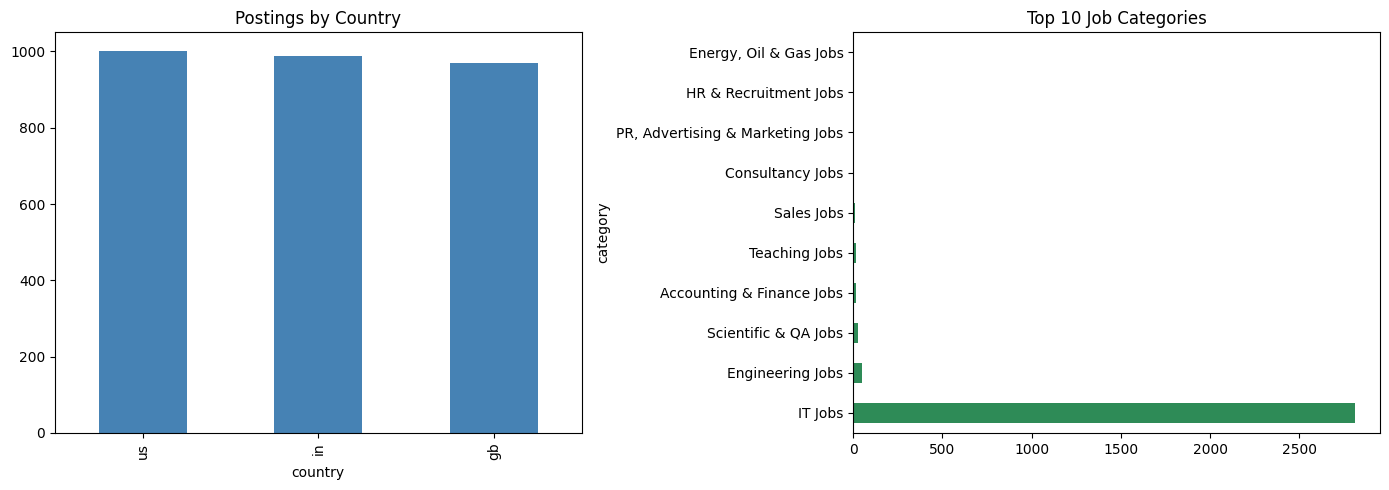

In [6]:
#----Distribution plots----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['country'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Postings by Country')
df['category'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 Job Categories')
plt.tight_layout()
plt.savefig('postings_distribution.png')
plt.show()

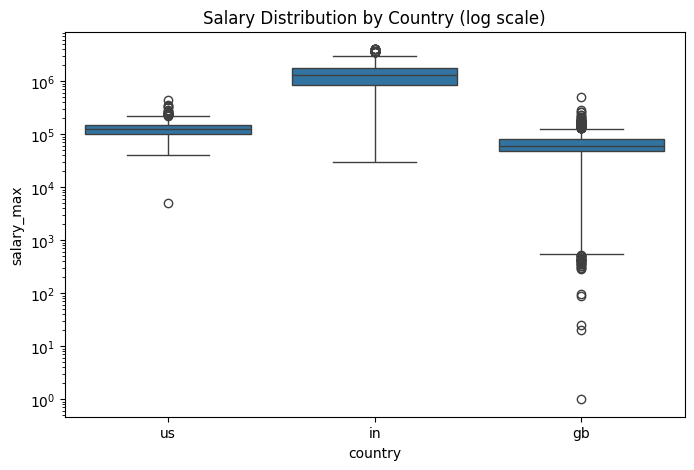

In [7]:
#---Salary distribution per country----
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_salary, x='country', y='salary_max')
plt.yscale('log')  # log scale since ranges differ hugely by currency
plt.title('Salary Distribution by Country (log scale)')
plt.savefig('salary_by_country.png')
plt.show()

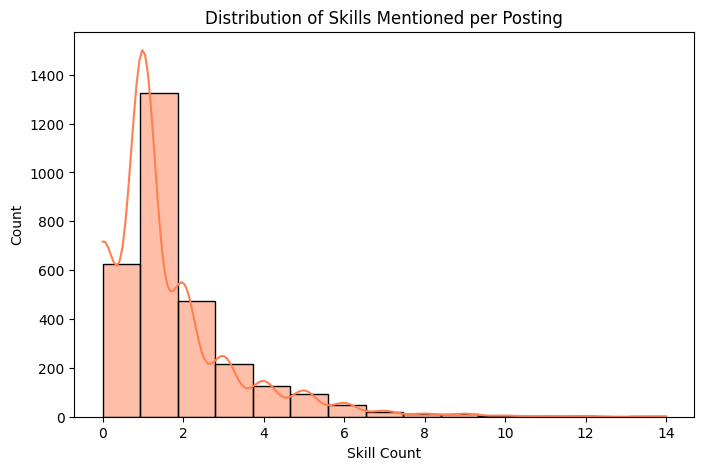

In [8]:
#----Skill count distribution-----
plt.figure(figsize=(8, 5))
sns.histplot(df['skill_count'], bins=15, kde=True, color='coral')
plt.title('Distribution of Skills Mentioned per Posting')
plt.xlabel('Skill Count')
plt.savefig('skill_count_distribution.png')
plt.show()

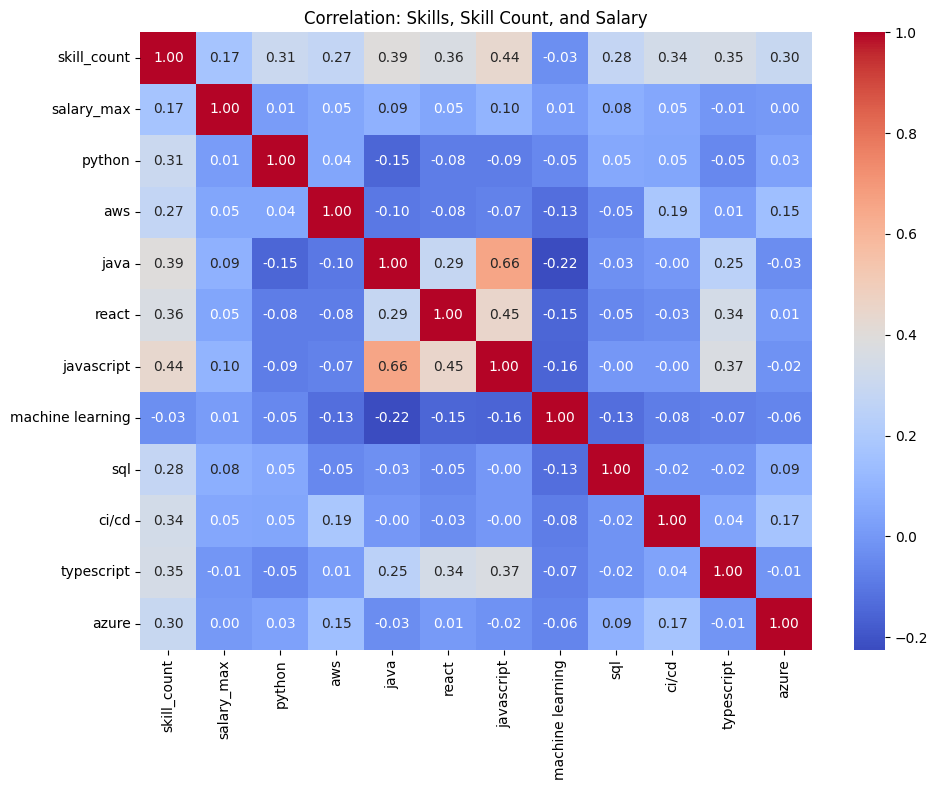

In [9]:
#---Correlation heatmap---
top_skills = freq_df['skill'].head(10).tolist()
for skill in top_skills:
    df[skill] = df['skills_str'].str.contains(skill, na=False).astype(int)

corr_cols = ['skill_count', 'salary_max'] + top_skills
corr_df = df[corr_cols].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Skills, Skill Count, and Salary')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [10]:
#---Which skills correlate most with higher salary----
salary_corr = corr_df.corr()['salary_max'].drop('salary_max').sort_values(ascending=False)
print(salary_corr)

skill_count         0.170476
javascript          0.098169
java                0.089380
sql                 0.080360
ci/cd               0.050120
react               0.047955
aws                 0.046240
python              0.013831
machine learning    0.013121
azure               0.002604
typescript         -0.006731
Name: salary_max, dtype: float64


In [11]:
findings = f"""
KEY FINDINGS - Exploratory Data Analysis
========================================
- Dataset: {len(df)} job postings across US, India, and GB.
- Missing salary data: {df['salary_max'].isna().sum()} postings ({df['salary_max'].isna().mean()*100:.1f}%).
- Salary comparisons normalized per-country due to mixed local currencies (INR vs USD vs GBP).
- Average skills mentioned per posting: {df['skill_count'].mean():.1f}.
- Skill most positively correlated with salary: {salary_corr.index[0]} (r={salary_corr.iloc[0]:.2f})
- Skill most negatively correlated with salary: {salary_corr.index[-1]} (r={salary_corr.iloc[-1]:.2f})
"""
with open('eda_key_findings.txt', 'w') as f:
    f.write(findings)
print(findings)


KEY FINDINGS - Exploratory Data Analysis
- Dataset: 2959 job postings across US, India, and GB.
- Missing salary data: 480 postings (16.2%).
- Salary comparisons normalized per-country due to mixed local currencies (INR vs USD vs GBP).
- Average skills mentioned per posting: 1.6.
- Skill most positively correlated with salary: skill_count (r=0.17)
- Skill most negatively correlated with salary: typescript (r=-0.01)



In [12]:
for f in ['postings_distribution.png', 'salary_by_country.png', 'skill_count_distribution.png', 'correlation_heatmap.png', 'eda_key_findings.txt']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>